# Поиск минимального числа каналов

In [7]:
from math import factorial
import matplotlib.pyplot as plt

# Исходные данные
alpha = 1.0
n = 36
k = 4

# Параметры СМО
lam = n / 24  # Интенсивность поступления заявок λ (заявок в час)
mu = 1 / alpha  # Интенсивность обслуживания μ (заявок в час)
a = lam / mu # Приведённая нагрузка (нагрузка в Эрлангах)

# ---------------------------------------
# Поиск минимального числа каналов
# ---------------------------------------

channels = []
refusal_probs = []
throughputs = []

min_channels = None

for m in range(1, 15):

    denominator = sum(a**i / factorial(i) for i in range(m + 1))

    p_refuse = (a**m / factorial(m)) / denominator
    q = 1 - p_refuse

    channels.append(m)
    refusal_probs.append(p_refuse)
    throughputs.append(q)

    if min_channels is None and q >= 0.95:
        min_channels = m

print(f"Минимальное число каналов: {min_channels}")

Минимальное число каналов: 4


# Характеристики для k = 4

In [8]:
denominator = sum(a**i / factorial(i) for i in range(k + 1))

probabilities = [
    (a**i / factorial(i)) / denominator
    for i in range(k + 1)
]

p_refuse = probabilities[-1]

Q = 1 - p_refuse
A = lam * Q

busy_channels = sum(
    i * probabilities[i]
    for i in range(k + 1)
)

load_factor = busy_channels / k

print("\nВероятности состояний:")

for i, p in enumerate(probabilities):
    print(f"P{i} = {p:.4f}")

print(f"\nВероятность отказа: {p_refuse:.4f}")
print(f"Относительная пропускная способность: {Q:.4f}")
print(f"Абсолютная пропускная способность: {A:.4f}")
print(f"Среднее число занятых каналов: {busy_channels:.4f}")
print(f"Коэффициент загрузки каналов: {load_factor:.4f}")


Вероятности состояний:
P0 = 0.2274
P1 = 0.3410
P2 = 0.2558
P3 = 0.1279
P4 = 0.0480

Вероятность отказа: 0.0480
Относительная пропускная способность: 0.9520
Абсолютная пропускная способность: 1.4281
Среднее число занятых каналов: 1.4281
Коэффициент загрузки каналов: 0.3570


# Графики

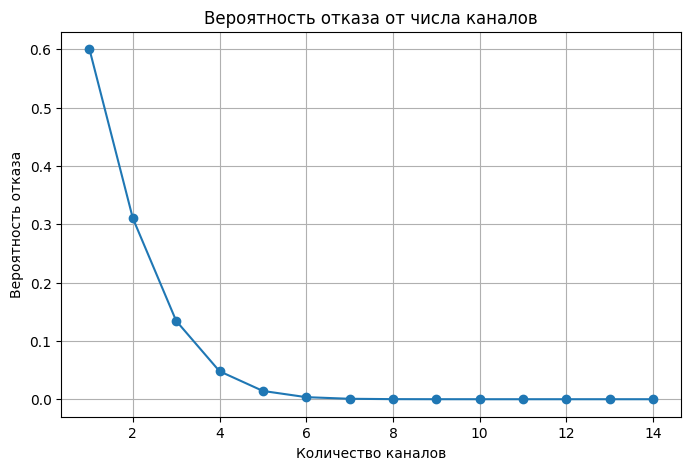

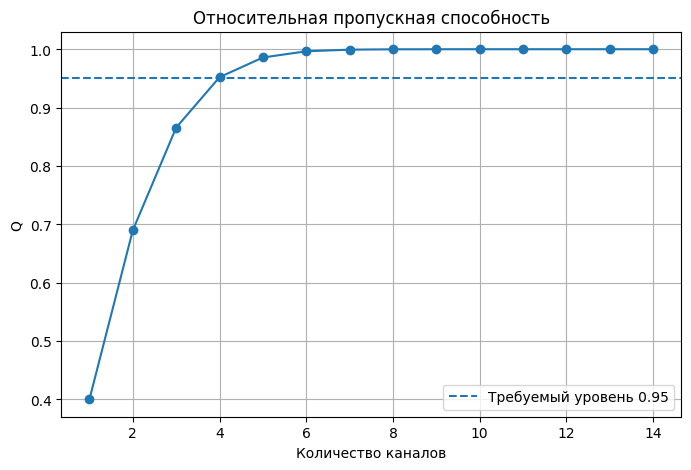

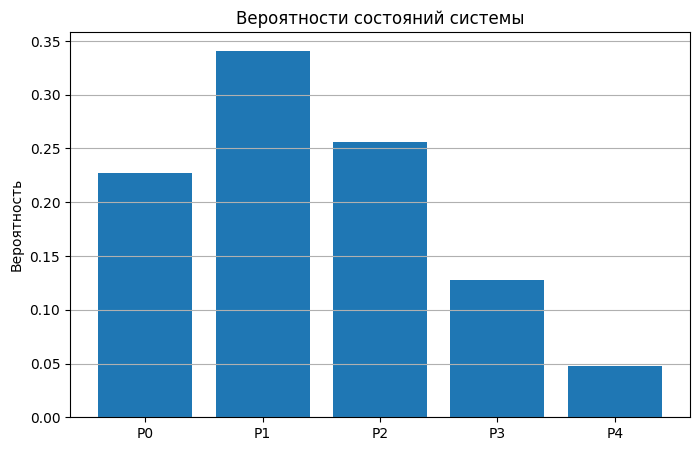

In [9]:
# ---------------------------------------
# График 1
# Вероятность отказа
# ---------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(channels, refusal_probs, marker='o')
plt.title("Вероятность отказа от числа каналов")
plt.xlabel("Количество каналов")
plt.ylabel("Вероятность отказа")
plt.grid(True)
plt.show()

# ---------------------------------------
# График 2
# Относительная пропускная способность
# ---------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(channels, throughputs, marker='o')
plt.axhline(
    y=0.95,
    linestyle='--',
    label='Требуемый уровень 0.95'
)
plt.title("Относительная пропускная способность")
plt.xlabel("Количество каналов")
plt.ylabel("Q")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------
# График 3
# Вероятности состояний
# ---------------------------------------

plt.figure(figsize=(8, 5))
plt.bar(
    [f'P{i}' for i in range(k + 1)],
    probabilities
)
plt.title("Вероятности состояний системы")
plt.ylabel("Вероятность")
plt.grid(axis='y')
plt.show()